# The Price is Right

Today we build a more complex solution for estimating prices of goods.

1. Day 2.0 notebook: create a RAG database with our 400,000 training data
2. Day 2.1 notebook: visualize in 2D
3. Day 2.2 notebook: visualize in 3D
4. Day 2.3 notebook: build and test a RAG pipeline with GPT-4o-mini
5. Day 2.4 notebook: (a) bring back our Random Forest pricer (b) Create a Ensemble pricer that allows contributions from all the pricers

Phew! That's a lot to get through in one day!

## PLEASE NOTE:

We already have a very powerful product estimator with our proprietary, fine-tuned LLM. Most people would be very satisfied with that! The main reason we're adding these extra steps is to deepen your expertise with RAG and with Agentic workflows.

## We will go fast today! Hold on to your hat..

In [1]:
# imports

import os
import re
import math
import json
from tqdm import tqdm
import random
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
import numpy as np
import pickle
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import chromadb
from items import Item
from testing import Tester

In [2]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HUGGING_FACE_TOKEN_WITH_LLAMA_ACCESS', 'your-key-if-not-using-env')

In [3]:
openai = OpenAI()

In [5]:
# Load in the test pickle file
# See the section "Back to the PKL files" in the day2.0 notebook
# for instructions on obtaining this test.pkl file

with open('../week6/test.pkl', 'rb') as file:
    test = pickle.load(file)

In [6]:
def make_context(similars, prices):
    message = "To provide some context, here are some other items that might be similar to the item you need to estimate.\n\n"
    for similar, price in zip(similars, prices):
        message += f"Potentially related product:\n{similar}\nPrice is ${price:.2f}\n\n"
    return message

In [7]:
def messages_for(item, similars, prices):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = make_context(similars, prices)
    user_prompt += "And now the question for you:\n\n"
    user_prompt += item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [8]:
DB = "products_vectorstore"

In [9]:
client = chromadb.PersistentClient(path=DB)
collection = client.get_or_create_collection('products')

In [10]:
def description(item):
    text = item.prompt.replace("How much does this cost to the nearest dollar?\n\n", "")
    return text.split("\n\nPrice is $")[0]

In [11]:
description(test[0])

'Arch Memory 4GB DDR3L 1866 MHz So-dimm RAM for Synology NAS Systems DiskStation DS718+\nCompatible with Synology 4GB 204 Pin Sodimm 1.35 volts; Single Rank (1Rx8) Access crucial data faster by upgrading your internal memory Rugged tier one ic chipsets; built for performance and security RAM 4 GB DDR3, Brand Arch Memory, model number Weight 2.08 ounces, Dimensions 2.13 x 0.06 x 1.19 inches, Dimensions LxWxH 2.13 x 0.06 x 1.19 inches, Voltage 1.35 Volts, Manufacturer Arch Memory,'

In [12]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

In [13]:
def vector(item):
    return model.encode([description(item)])

In [14]:
def find_similars(item):
    results = collection.query(query_embeddings=vector(item).astype(float).tolist(), n_results=5)
    documents = results['documents'][0][:]
    prices = [m['price'] for m in results['metadatas'][0][:]]
    return documents, prices

In [15]:
print(test[1].prompt)

How much does this cost to the nearest dollar?

Dreamus LIGHTSUM - Into The Light 1st Mini Album+Folded Poster (Random ver.), 150 x 175 x 32 mm
🎈KPOP MARKET (HANTEO & GAON Chart Family Shop) will ship your order from South Korea. 📆Release Date 🎵CD + 84p Booklet + Lyric Paper + Photocard (Random 1 out of 8) + Scratch Card (Random 1 out of 8) + Mini Poster (Random 1 out of 8) + ID Card (Pre-Order Only) 📌100% Original Brand New Item. Sales volume is reflected in the HANTEO and GAON Charts. 🎁 Safe packaging with traceable delivery

Price is $26.00


In [16]:
documents, prices = find_similars(test[1])

In [17]:
print(make_context(documents, prices))

To provide some context, here are some other items that might be similar to the item you need to estimate.

Potentially related product:
Dreamus KEY SHINee - Gasoline VHS ver. 2nd Album (No Poster)
KPOP MARKET (HANTEO & GAON Chart Family Shop) will ship your order from South Korea. Release Date # Poster is Not Included. FREE GIFT Double-Side Extra Photocards Set (KPOP MARKET Store Gift) 100% Original Brand New Item. Sales volume is reflected in the HANTEO and GAON Charts. s 1, Orientation Landscape, Shape Square, Frame Type Framed, Wall Art Form Poster, Contributor KEY (SHINee), Style Modern, Brand Dreamus, Mounting Type Wall Mount, Dimensions 9.8 x 6.22 x 1.65 inches, Weight 1.32
Price is $31.99

Potentially related product:
EXO XIUMIN - 1st Mini Album 'Brand New' photobook SET ver + Pre-order Folded poster
EXO XIUMIN - 1st Mini Album 'Brand New' 📓 EXO XIUMIN - 1st Mini Album 'Brand New' 🎀 Seller Gift Extra photocard set, Top ggu sticker 📅 Released on Sep 26th, 2022 We will send the b

In [18]:
print(messages_for(test[1], documents, prices))

[{'role': 'system', 'content': 'You estimate prices of items. Reply only with the price, no explanation'}, {'role': 'user', 'content': "To provide some context, here are some other items that might be similar to the item you need to estimate.\n\nPotentially related product:\nDreamus KEY SHINee - Gasoline VHS ver. 2nd Album (No Poster)\nKPOP MARKET (HANTEO & GAON Chart Family Shop) will ship your order from South Korea. Release Date # Poster is Not Included. FREE GIFT Double-Side Extra Photocards Set (KPOP MARKET Store Gift) 100% Original Brand New Item. Sales volume is reflected in the HANTEO and GAON Charts. s 1, Orientation Landscape, Shape Square, Frame Type Framed, Wall Art Form Poster, Contributor KEY (SHINee), Style Modern, Brand Dreamus, Mounting Type Wall Mount, Dimensions 9.8 x 6.22 x 1.65 inches, Weight 1.32\nPrice is $31.99\n\nPotentially related product:\nEXO XIUMIN - 1st Mini Album 'Brand New' photobook SET ver + Pre-order Folded poster\nEXO XIUMIN - 1st Mini Album 'Brand 

In [19]:
def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [20]:
get_price("The price for this is $99.99")

99.99

In [21]:
# The function for gpt-4o-mini

def gpt_4o_mini_rag(item):
    documents, prices = find_similars(item)
    response = openai.chat.completions.create(
        model="gpt-4o-mini", 
        messages=messages_for(item, documents, prices),
        seed=42,
        max_tokens=5
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [22]:
gpt_4o_mini_rag(test[1])

38.99

In [23]:
test[1].price

25.99

1: Guess: $29.95 Truth: $28.95 Error: $1.00 SLE: 0.00 Item: Arch Memory AM-D3NS1866L-4G 4GB 204-Pin ...
2: Guess: $38.99 Truth: $25.99 Error: $13.00 SLE: 0.15 Item: Dreamus LIGHTSUM - Into The Light 1st Mi...
3: Guess: $149.99 Truth: $260.00 Error: $110.01 SLE: 0.30 Item: Belden 1613AP, Plenum Rated RG6 Coaxial ...
4: Guess: $299.99 Truth: $419.99 Error: $120.00 SLE: 0.11 Item: Garmin Enduro, Ultraperformance Multispo...
5: Guess: $249.99 Truth: $279.99 Error: $30.00 SLE: 0.01 Item: JOYLDIAS Kids Ride On Police Car, 12V Ba...
6: Guess: $34.99 Truth: $62.02 Error: $27.03 SLE: 0.31 Item: Middle Atlantic Products The Brush Gromm...
7: Guess: $249.00 Truth: $190.49 Error: $58.51 SLE: 0.07 Item: Canon EF-M 22mm f2 STM Compact System Fi...
8: Guess: $160.99 Truth: $120.99 Error: $40.00 SLE: 0.08 Item: VideoSecu 700TVL Day Night IR CCTV Wide ...
9: Guess: $89.99 Truth: $153.67 Error: $63.68 SLE: 0.28 Item: Pioneer Pioneer SE-M521 Headphone Sealed...
10: Guess: $110.00 Truth: $91.99 Error: $18

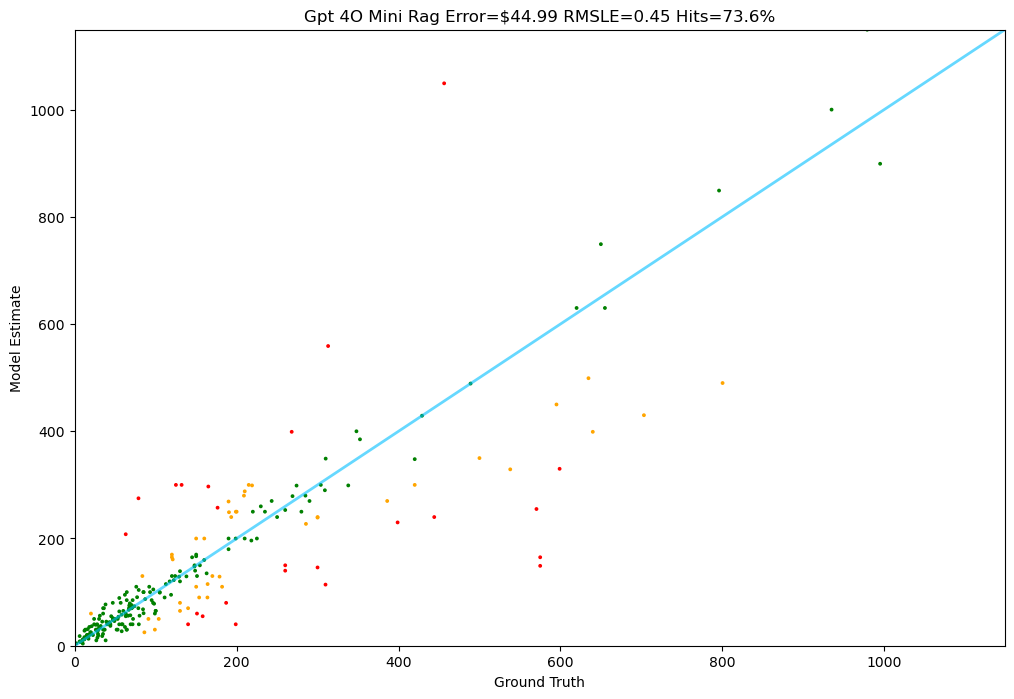

In [24]:
Tester.test(gpt_4o_mini_rag, test)

## Optional Extra: Trying a DeepSeek API call instead of OpenAI

If you have a DeepSeek API key, we will use it here as an alternative implementation; otherwise skip to the next section..

In [ ]:
# Connect to DeepSeek using the OpenAI client python library

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")
deepseek_via_openai_client = OpenAI(api_key=deepseek_api_key,base_url="https://api.deepseek.com")

In [ ]:
# Added some retry logic here because DeepSeek is very oversubscribed and sometimes fails..

def deepseek_api_rag(item):
    documents, prices = find_similars(item)
    retries = 8
    done = False
    while not done and retries > 0:
        try:
            response = deepseek_via_openai_client.chat.completions.create(
                model="deepseek-chat", 
                messages=messages_for(item, documents, prices),
                seed=42,
                max_tokens=8
            )
            reply = response.choices[0].message.content
            done = True
        except Exception as e:
            print(f"Error: {e}")
            retries -= 1
    return get_price(reply)

In [ ]:
deepseek_api_rag(test[1])

In [ ]:
Tester.test(deepseek_api_rag, test)

## And now to wrap this in an "Agent" class

In [25]:
from agents.frontier_agent import FrontierAgent

In [26]:
# Let's print the logs so we can see what's going on

import logging
root = logging.getLogger()
root.setLevel(logging.INFO)

In [27]:
agent = FrontierAgent(collection)

INFO:root:[Frontier Agent] Initializing Frontier Agent
INFO:root:[Frontier Agent] Frontier Agent is set up with DeepSeek
INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: mps
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:root:[Frontier Agent] Frontier Agent is ready


In [28]:
agent.price("Quadcast HyperX condenser mic for high quality podcasting")

INFO:root:[Frontier Agent] Frontier Agent is performing a RAG search of the Chroma datastore to find 5 similar products


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:[Frontier Agent] Frontier Agent has found similar products
INFO:root:[Frontier Agent] Frontier Agent is about to call deepseek-chat with context including 5 similar products
INFO:httpx:HTTP Request: POST https://api.deepseek.com/chat/completions "HTTP/1.1 200 OK"
INFO:root:[Frontier Agent] Frontier Agent completed - predicting $119.99


119.99

In [29]:
from agents.specialist_agent import SpecialistAgent

In [30]:
agent2 = SpecialistAgent()

INFO:root:[Specialist Agent] Specialist Agent is initializing - connecting to modal
/opt/homebrew/Caskroom/miniforge/base/envs/llms/lib/python3.11/asyncio/events.py:84: DeprecationError: 2025-01-27: `modal.Cls.lookup` is deprecated and will be removed in a future release. It can be replaced with `modal.Cls.from_name`.

See https://modal.com/docs/guide/modal-1-0-migration for more information.
  self._context.run(self._callback, *self._args)
INFO:root:[Specialist Agent] Specialist Agent is ready


In [31]:
agent2.price("Quadcast HyperX condenser mic for high quality podcasting")

INFO:root:[Specialist Agent] Specialist Agent is calling remote fine-tuned model
INFO:root:[Specialist Agent] Specialist Agent completed - predicting $220.00


220.0